In [ ]:
# 1. Install necessary libraries
!pip install -q transformers datasets evaluate accelerate

# 2. Set up Kaggle API (It will prompt you to upload your kaggle.json file)
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Move the uploaded file to the required directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download and unzip the Chest X-Ray dataset
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
print("Unzipping dataset (this might take a minute)...")
!unzip -q chest-xray-pneumonia.zip
print("Dataset downloaded and ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 219MB/s]

Unzipping dataset (this might take a minute)...
Dataset downloaded and ready!


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the paths based on the unzipped Kaggle dataset
data_dir = 'chest_xray/chest_xray'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# 1. Preprocessing & Augmentation Pipelines
# ImageNet normalization statistics (standard for pre-trained ViT models)
norm_mean = [0.5, 0.5, 0.5]
norm_std = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # Resize to 224x224 for ViT
    transforms.RandomHorizontalFlip(),       # Data Augmentation: Flip
    transforms.RandomRotation(15),           # Data Augmentation: Slight rotation
    transforms.ToTensor(),                   # Convert image to PyTorch Tensor
    transforms.Normalize(mean=norm_mean, std=norm_std) # Normalize pixels
])

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # Testing/Val data only needs resizing
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# 2. Load Datasets using ImageFolder
print("Loading datasets...")
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_val_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_val_transform)

# 3. Create Data Loaders for batch processing
batch_size = 32  # Standard mini-batch size as per the paper
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Print Verification Data
print(f"✅ Preprocessing Complete!")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")
print(f"Detected Classes: {train_dataset.classes}")

Loading datasets...
✅ Preprocessing Complete!
Number of training images: 5216
Number of validation images: 16
Number of testing images: 624
Detected Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
import torch  # <-- Added this line to fix the NameError!
from transformers import ViTForImageClassification

# 1. Choose the pre-trained Vision Transformer model variant
model_name = 'google/vit-base-patch16-224'

print("Downloading and configuring pre-trained Vision Transformer...")

# 2. Load the model with a custom classification head
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,  # We only have 2 classes: Normal and Pneumonia
    id2label={0: 'NORMAL', 1: 'PNEUMONIA'},
    label2id={'NORMAL': 0, 'PNEUMONIA': 1},
    ignore_mismatched_sizes=True  # Overwrites the original 1000-class head
)

# 3. Move the model to the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model successfully loaded and moved to: {device.type.upper()}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model successfully loaded and moved to: CUDA


In [ ]:
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# 1. Define the Loss Function and Optimizer as specified in the methodology
# CrossEntropyLoss measures how well the model predicts the binary classes (Normal vs Pneumonia)
criterion = nn.CrossEntropyLoss()

# Adam optimizer is preferred for Vision Transformers
# We use a very gentle learning rate (2e-5) so we don't destroy the pre-trained weights
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 2. Training Configurations
num_epochs = 5  # You can start with 5 epochs to see how it performs
best_val_loss = float('inf')

print("Starting the Training Process...\n")

# 3. The Core Training and Validation Loop
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()  # Tell the model it is in training mode (enables dropout)
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Progress bar loop over the mini-batches
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)  # Move data to GPU

        optimizer.zero_grad()  # Clear any old mathematical gradients

        # Forward pass: Feed images into the ViT brain
        outputs = model(images)
        logits = outputs.logits  # Extract raw prediction scores

        loss = criterion(logits, labels)  # Grade the predictions
        loss.backward()  # Backpropagation: Calculate the mistakes
        optimizer.step()  # Update the model weights

        # Calculate training statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Update progress bar text on the fly
        train_bar.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- VALIDATION PHASE ---
    model.eval()  # Tell the model it is in evaluation mode (disables dropout)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Disable gradient tracking to save graphics card memory and run faster
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            logits = outputs.logits
            loss = criterion(logits, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    # Print summary metrics for the finished epoch
    print(f"\n📢 Epoch {epoch+1} Results:")
    print(f"   📊 Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.2f}%")
    print(f"   🧪 Val Loss:   {epoch_val_loss:.4f} | Val Accuracy:   {epoch_val_acc:.2f}%")

    # Save the absolute best model weights based on Validation Loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_vit_pneumonia_model.pth')
        print("   ⭐ Best model saved successfully!")
    print("-" * 50)

print("\n🎉 Training Complete!")

Starting the Training Process...



Epoch 1/5 [Train]:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]


📢 Epoch 1 Results:
   📊 Train Loss: 0.1325 | Train Accuracy: 94.56%
   🧪 Val Loss:   0.3865 | Val Accuracy:   81.25%
   ⭐ Best model saved successfully!
--------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]


📢 Epoch 4 Results:
   📊 Train Loss: 0.0339 | Train Accuracy: 98.85%
   🧪 Val Loss:   0.8801 | Val Accuracy:   62.50%
--------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]


📢 Epoch 5 Results:
   📊 Train Loss: 0.0381 | Train Accuracy: 98.62%
   🧪 Val Loss:   0.1326 | Val Accuracy:   93.75%
--------------------------------------------------

🎉 Training Complete!


Loading the best trained model weights...
Evaluating the Vision Transformer on the test dataset...

================ FINAL EVALUATION REPORT ================
📊 Test Accuracy:  84.29%
🎯 Precision:      80.29%
🩸 Recall (Sens):  99.23%
⚖️  F1-Score:       88.76%

True Negatives (Healthy lungs correctly identified): 139
False Positives (Healthy lungs mistaken for Pneumonia): 95
False Negatives (Pneumonia cases MISSED by AI): 3 ⚠️
True Positives (Pneumonia cases correctly identified): 387


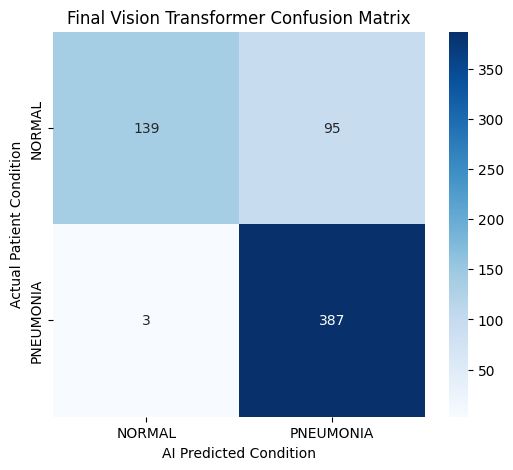

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Load the absolute best weights saved during the training phase
print("Loading the best trained model weights...")
model.load_state_dict(torch.load('best_vit_pneumonia_model.pth'))
model.to(device)
model.eval()  # Set model to evaluation mode

all_preds = []
all_labels = []

print("Evaluating the Vision Transformer on the test dataset...")

# 2. Loop through the test dataset conveyor belt
with torch.no_grad():  # Turn off gradient engine to save memory
    for images, labels in test_loader:
        images = images.to(device)

        # Get predictions from the ViT brain
        outputs = model(images)
        logits = outputs.logits

        # Pick the highest score class (0 for Normal, 1 for Pneumonia)
        _, preds = torch.max(logits, 1)

        # Save results to calculate scores
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Calculate the exact mathematical formulas from your paper
acc = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds) * 100
recall = recall_score(all_labels, all_preds) * 100
f1 = f1_score(all_labels, all_preds) * 100

# Print final report
print("\n================ FINAL EVALUATION REPORT ================")
print(f"📊 Test Accuracy:  {acc:.2f}%")
print(f"🎯 Precision:      {precision:.2f}%")
print(f"🩸 Recall (Sens):  {recall:.2f}%")
print(f"⚖️  F1-Score:       {f1:.2f}%")
print("=========================================================\n")

# 4. Generate and Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Healthy lungs correctly identified): {tn}")
print(f"False Positives (Healthy lungs mistaken for Pneumonia): {fp}")
print(f"False Negatives (Pneumonia cases MISSED by AI): {fn} ⚠️")
print(f"True Positives (Pneumonia cases correctly identified): {tp}")

# Visualizing the matrix as a heatmap graph
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.ylabel('Actual Patient Condition')
plt.xlabel('AI Predicted Condition')
plt.title('Final Vision Transformer Confusion Matrix')
plt.show()